In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
from scipy import stats
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
from src.data_loader import load_data, remove_nulls,show_duplicates,fill_nulls
from src.analysis import calculate_ema,calculate_sma,calculate_rsi,identify_rsi_signals,calculate_macd,calculate_macd_last_2_years,calculate_bollinger_bands,calculate_volatility,calculate_max_drawdown,calculate_bollinger_bands_2years
from src.plot import plot_bollinger_bands,plot_volatility,plot_price_with_moving_averages,plot_price_with_bollinger_bands



[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\bemnet\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\bemnet\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


# LOAD DATA

In [2]:
df = load_data("../data/raw/Data/META.csv")
df.head()

,Date,Close,High,Low,Open,Volume
0,2012-05-18,37.995762,44.724282,37.767172,41.792356,573576400
1,2012-05-21,33.821495,36.435382,32.797807,36.306177,168192700
2,2012-05-22,30.810066,33.384198,30.750434,32.410203,101786600
3,2012-05-23,31.803938,32.300874,31.167860,31.177799,73600000
4,2012-05-24,32.827625,33.006523,31.575347,32.748117,50237200


#  DATA PREPARATION

In [3]:

# 1. Normalize timestamps (convert to timezone-naive)
# convert to datetime
df['Date'] = pd.to_datetime(df['Date'])

# make timezone-naive
df['Date'] = df['Date'].dt.tz_localize(None)

# verify
print(df['Date'].head())

# 2. Ensure columns are correctly typed
df = df.astype({'Open': 'float64', 'High': 'float64', 'Low': 'float64', 'Close': 'float64', 'Volume': 'float64'})

0   2012-05-18
1   2012-05-21
2   2012-05-22
3   2012-05-23
4   2012-05-24
Name: Date, dtype: datetime64[ns]


# HANDLE MISSING VALUES


In [4]:
df = fill_nulls(df)
df = remove_nulls(df)
df.head()

No missing values found.


Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

No missing values found. All 2923 rows kept.


,Date,Close,High,Low,Open,Volume
0,2012-05-18,37.995762,44.724282,37.767172,41.792356,573576400.0
1,2012-05-21,33.821495,36.435382,32.797807,36.306177,168192700.0
2,2012-05-22,30.810066,33.384198,30.750434,32.410203,101786600.0
3,2012-05-23,31.803938,32.300874,31.167860,31.177799,73600000.0
4,2012-05-24,32.827625,33.006523,31.575347,32.748117,50237200.0


# Technical Indicators with TA-Lib

In [5]:
df = df.sort_values('Date')
df = calculate_sma(
    df,
    column='Close',
    windows=[20,50,100]
)

# calculate EMA
df = calculate_ema(
    df,
    column='Close',
    windows=[20,50,100]
)

# display results
print(df.tail(20))

           Date       Close        High         Low        Open      Volume  \
2903 2023-12-01  322.829865  324.857344  318.794742  323.485824  15276400.0   
2904 2023-12-04  318.059204  318.894054  311.738187  315.345950  19037100.0   
2905 2023-12-05  316.339813  319.907813  313.457588  317.025588  16952100.0   
2906 2023-12-06  315.505005  320.275583  315.097513  319.957537  11294300.0   
2907 2023-12-07  324.588989  326.228874  315.823022  315.823022  15905100.0   
2908 2023-12-08  330.711273  331.128713  321.021010  321.110455  14087400.0   
2909 2023-12-11  323.287018  327.868788  318.039369  327.381770  25802500.0   
2910 2023-12-12  332.172241  332.420709  322.571424  322.611188  18485500.0   
2911 2023-12-13  332.689087  336.296851  330.601978  331.884052  16353300.0   
2912 2023-12-14  331.128693  332.649317  326.626449  331.804519  19607300.0   
2913 2023-12-15  332.867981  336.585057  329.190638  329.955910  31776900.0   
2914 2023-12-18  342.508514  345.430504  334.955073 

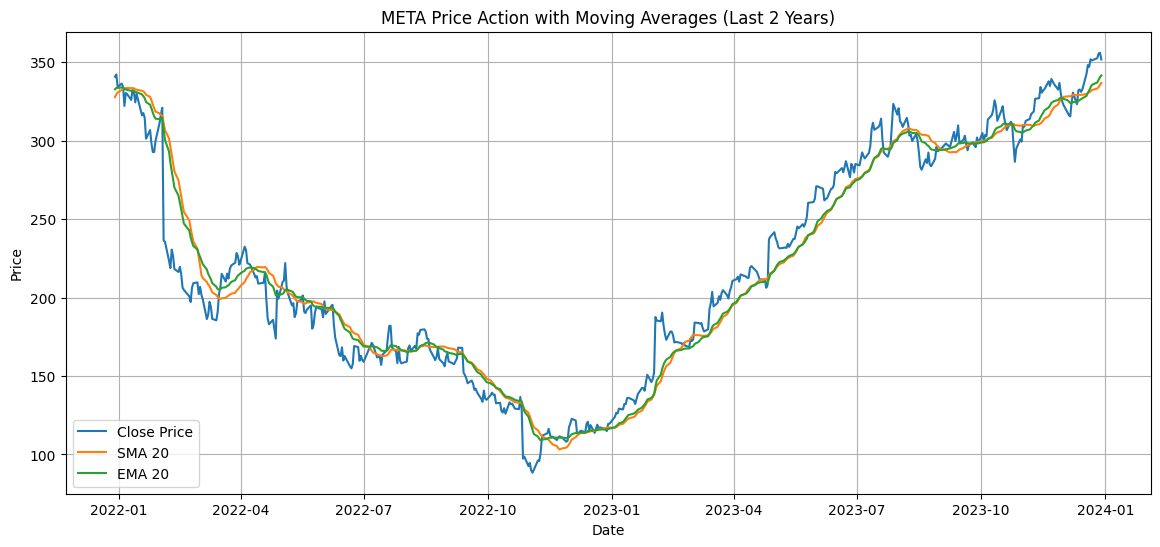

In [6]:
plot_price_with_moving_averages(
    df,
    ticker='META'
)

### Moving Average Analysis Summary

- The stock showed a strong long-term upward trend, especially after 2019.
- SMA and EMA closely followed the closing price, confirming the overall market direction.
- EMA reacted more quickly to short-term price fluctuations, while SMA appeared smoother and lagged slightly behind price movements.
- Periods where moving averages moved sharply upward reflected strong bullish momentum and increased market activity.
- Higher volatility was observed between 2020 and 2023, with larger price swings and rapid trend changes.

### Relative Strength Index(RSI)

In [7]:
df = calculate_rsi(
    df,
    column='Close',
    period=14
)

In [ ]:
df = identify_rsi_signals(df)

print(
    df[
        ['Date', 'Close', 'RSI', 'Overbought', 'Oversold']
    ].tail(20)
)

           Date       Close        RSI  Overbought  Oversold
2903 2023-12-01  322.829865  48.710622       False     False
2904 2023-12-04  318.059204  44.696066       False     False
2905 2023-12-05  316.339813  43.310621       False     False
2906 2023-12-06  315.505005  42.619859       False     False
2907 2023-12-07  324.588989  51.655440       False     False
2908 2023-12-08  330.711273  56.614106       False     False
2909 2023-12-11  323.287018  49.926476       False     False
2910 2023-12-12  332.172241  56.542703       False     False
2911 2023-12-13  332.689087  56.899452       False     False
2912 2023-12-14  331.128693  55.420254       False     False
2913 2023-12-15  332.867981  56.769317       False     False
2914 2023-12-18  342.508514  63.383621       False     False
2915 2023-12-19  348.213318  66.636636       False     False
2916 2023-12-20  347.139984  65.458340       False     False
2917 2023-12-21  351.920502  68.158903       False     False
2918 2023-12-22  351.224

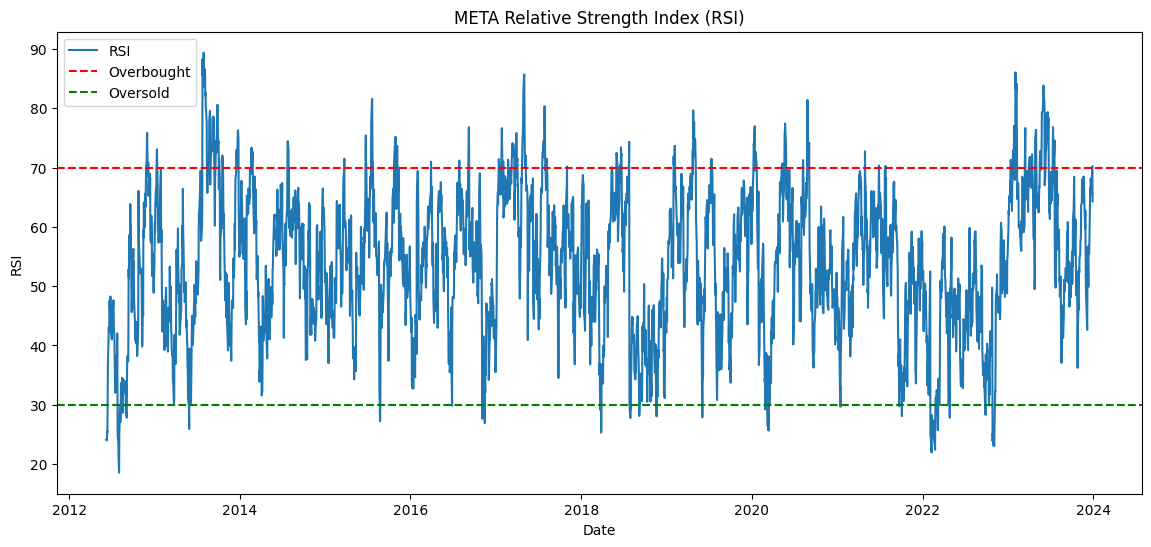

In [10]:
plt.figure(figsize=(14,6))

plt.plot(
    df['Date'],
    df['RSI'],
    label='RSI'
)

# overbought line
plt.axhline(
    70,
    color='red',
    linestyle='--',
    label='Overbought'
)

# oversold line
plt.axhline(
    30,
    color='green',
    linestyle='--',
    label='Oversold'
)

plt.xlabel("Date")
plt.ylabel("RSI")

plt.title("META Relative Strength Index (RSI)")

plt.legend()

plt.show()

#### RSI Analysis Summary

- The RSI fluctuated frequently between overbought and oversold levels, indicating changing market momentum over time.
- Several periods crossed above the 70 threshold, suggesting temporary overbought conditions and potential price pullbacks.
- Multiple dips below the 30 threshold indicated oversold conditions, which may signal possible buying opportunities or price rebounds.
- Most RSI values remained within the neutral range (30–70), reflecting normal market trading behavior during much of the period.

### MACD (Moving Average Convergence Divergence)


#### MACD For The Last 2 Years

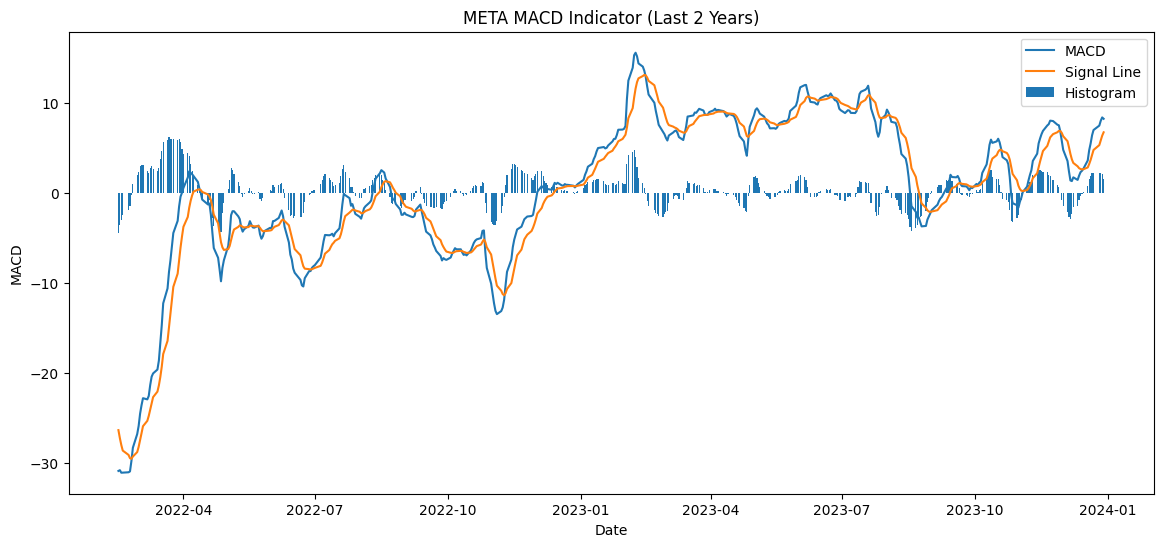

In [11]:
# calculate MACD for last 2 years
macd_df = calculate_macd_last_2_years(df)
plt.figure(figsize=(14,6))

# MACD line
plt.plot(
    macd_df['Date'],
    macd_df['MACD'],
    label='MACD'
)

# Signal line
plt.plot(
    macd_df['Date'],
    macd_df['MACD_Signal'],
    label='Signal Line'
)

# Histogram
plt.bar(
    macd_df['Date'],
    macd_df['MACD_Histogram'],
    label='Histogram'
)

plt.xlabel("Date")
plt.ylabel("MACD")

plt.title("META MACD Indicator (Last 2 Years)")

plt.legend()

plt.show()

#### MACD Comparison Summary

- The 2-year MACD chart shows recent market movements more clearly than the full historical chart.
- Several crossings between the MACD and signal line show frequent changes between upward and downward trends.
- Strong upward momentum appeared during parts of 2022 and 2023, while some periods showed clear downward pressure.
- Compared to the previous chart, the shorter timeframe makes recent market trends and momentum changes easier to see.

# Financial Metrics

### Volatility
Measures how much stock prices fluctuate over time using the standard deviation of returns. Higher volatility indicates higher risk.

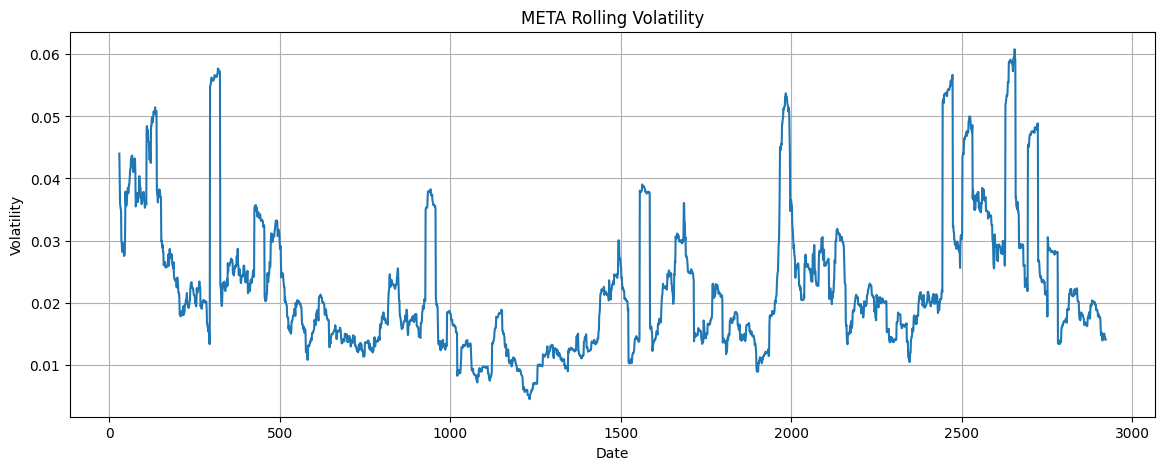

In [12]:
df = calculate_volatility(df)
plot_volatility(df, "META")

#### Rolling Volatility Analysis

The rolling volatility analysis for AAPL over the last two years shows generally moderate market fluctuations, with volatility mostly ranging between 0.01 and 0.03. Several short-term spikes were observed, including a major peak above 0.06, indicating periods of increased market uncertainty and strong price movements. Toward the end of the period, volatility declined and stabilized, suggesting reduced market risk and calmer trading conditions.

### Bollinger Bands
A volatility indicator consisting of upper and lower bands around a moving average to identify overbought or oversold conditions.

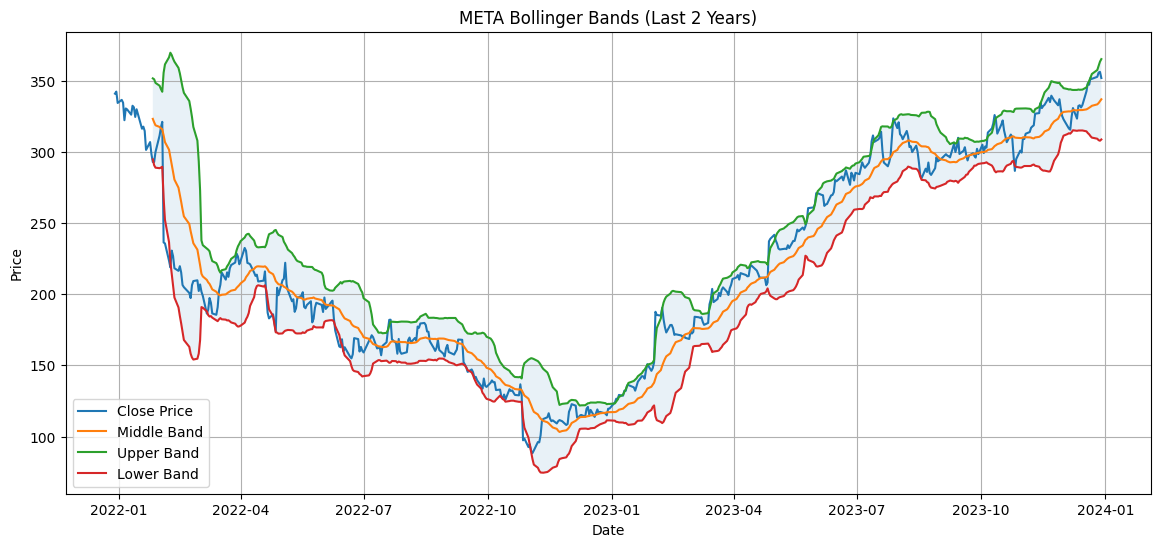

In [14]:
# Calculate Bollinger Bands
df_bollinger = calculate_bollinger_bands_2years(
    df,
    price_column='Close',
    date_column='Date',
    window=20,
    num_std=2
)
# Plot
plot_bollinger_bands(
    df_bollinger,
    ticker='META',
    price_column='Close',
    date_column='Date',
    window=20
)

#### Bollinger Bands Analysis

The Bollinger Bands analysis for AAPL over the latest two years shows periods of both high and low market volatility. Wider bands indicate increased price fluctuations and higher market uncertainty, particularly during strong upward and downward price movements. Narrower bands reflect more stable trading periods with lower volatility. The stock price frequently moved near the upper band during bullish trends and near the lower band during market declines, highlighting changing market momentum throughout the period.